<a href="https://colab.research.google.com/github/yasuminu/flight-sounds/blob/main/leadlag_colab_1_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 部分空間正則化PCA 日米業種リードラグ投資戦略
**論文**: 中川慧, 竹本悠城, 久保健治, 加藤真大 (SIG-FIN-036-13)

Google Colabで実行できます。上から順にセルを実行してください。

## 0. ライブラリインストール

In [ ]:
!pip install yfinance pandas-datareader -q

## 1. インポートと設定

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# --- ティッカー ---
US_TICKERS = ["XLB","XLC","XLE","XLF","XLI","XLK","XLP","XLRE","XLU","XLV","XLY"]
JP_TICKERS = ["1617.T","1618.T","1619.T","1620.T","1621.T","1622.T","1623.T",
              "1624.T","1625.T","1626.T","1627.T","1628.T","1629.T","1630.T",
              "1631.T","1632.T","1633.T"]
US_CYCLICAL  = ["XLB","XLE","XLF","XLRE"]
US_DEFENSIVE = ["XLK","XLP","XLU","XLV"]
JP_CYCLICAL  = ["1618.T","1625.T","1629.T","1631.T"]
JP_DEFENSIVE = ["1617.T","1621.T","1627.T","1630.T"]

# --- ハイパーパラメータ ---
START_DATE   = "2010-01-01"
END_DATE     = "2025-12-31"
PRETRAIN_END = "2014-12-31"
L      = 60    # ローリングウィンドウ(営業日)
K      = 3     # 共通ファクター数
LAMBDA = 0.9   # 正則化強度
Q      = 0.3   # ロング/ショート分位点

print("設定完了")

設定完了


## 2. データ取得
> TOPIX-17 ETFはyfinanceで取得できない場合があります。その場合は合成データで動作確認できます。

In [ ]:
USE_SYNTHETIC = False  # ← True にすると合成データで実行

def fetch_real_data():
    all_tickers = US_TICKERS + JP_TICKERS
    print(f"Downloading {len(all_tickers)} tickers...")
    raw   = yf.download(all_tickers, start=START_DATE, end=END_DATE, auto_adjust=True, progress=True)
    close = raw["Close"][all_tickers].ffill()
    open_ = raw["Open"][all_tickers].ffill()
    idx   = close.dropna(thresh=len(all_tickers)//2).index
    close, open_ = close.loc[idx], open_.loc[idx]
    us_avail = [t for t in US_TICKERS if close[t].notna().mean() > 0.5]
    jp_avail = [t for t in JP_TICKERS if close[t].notna().mean() > 0.5]
    print(f"US: {len(us_avail)} tickers, JP: {len(jp_avail)} tickers available")
    return (close[us_avail].pct_change(),
            close[jp_avail].pct_change(),
            close[jp_avail]/open_[jp_avail]-1,
            us_avail, jp_avail)

def generate_synthetic_data(seed=42):
    """論文の因子モデル(式23-24)に基づく合成データ"""
    rng   = np.random.default_rng(seed)
    dates = pd.bdate_range(START_DATE, END_DATE)
    T, NU, NJ = len(dates), len(US_TICKERS), len(JP_TICKERS)
    V_star = _build_prior_subspace(US_TICKERS, JP_TICKERS)
    gt     = rng.normal(0, 0.015, (T, K))
    eps    = rng.normal(0, 0.010, (T, NU+NJ))
    z_cc   = gt @ V_star.T + eps
    gt_lag = np.roll(gt, 1, axis=0); gt_lag[0] = 0
    z_oc   = 0.5 * gt_lag @ V_star[NU:,:].T + rng.normal(0, 0.008, (T, NJ))
    ret_cc = pd.DataFrame(z_cc, index=dates, columns=US_TICKERS+JP_TICKERS)
    jp_oc  = pd.DataFrame(z_oc,  index=dates, columns=JP_TICKERS)
    print(f"合成データ: {T}日, US={NU}銘柄, JP={NJ}銘柄")
    return ret_cc[US_TICKERS], ret_cc[JP_TICKERS], jp_oc, US_TICKERS, JP_TICKERS

if USE_SYNTHETIC:
    us_cc, jp_cc, jp_oc, us_cols, jp_cols = generate_synthetic_data()
else:
    us_cc, jp_cc, jp_oc, us_cols, jp_cols = fetch_real_data()

print(f"期間: {us_cc.index[0].date()} ~ {us_cc.index[-1].date()}  ({len(us_cc)}営業日)")

[                       0%                       ]

[*********************100%***********************]  28 of 28 completed


US: 10 tickers, JP: 17 tickers available
期間: 2010-01-04 ~ 2025-12-30  (4159営業日)


## 3. 事前部分空間 V0・C0 の構築 (論文§3.1)

In [ ]:
def _build_prior_subspace(us_cols, jp_cols):
    """V0=[v1,v2,v3]: グローバル / 国スプレッド / シクリカル-ディフェンシブ"""
    all_cols = us_cols + jp_cols
    N = len(all_cols)
    idx = {c:i for i,c in enumerate(all_cols)}

    v1 = np.ones(N) / np.sqrt(N)

    v2 = np.zeros(N)
    for c in us_cols: v2[idx[c]] =  1.0
    for c in jp_cols: v2[idx[c]] = -1.0
    v2 -= (v2@v1)*v1;  v2 /= np.linalg.norm(v2)+1e-12

    v3 = np.zeros(N)
    for c in US_CYCLICAL:
        if c in idx: v3[idx[c]] =  1.0
    for c in US_DEFENSIVE:
        if c in idx: v3[idx[c]] = -1.0
    for c in JP_CYCLICAL:
        if c in idx: v3[idx[c]] =  1.0
    for c in JP_DEFENSIVE:
        if c in idx: v3[idx[c]] = -1.0
    v3 -= (v3@v1)*v1 + (v3@v2)*v2;  v3 /= np.linalg.norm(v3)+1e-12

    return np.column_stack([v1, v2, v3])   # (N, 3)

def build_C0(V0, C_full):
    """式(10)-(12): 事前エクスポージャー行列 C0"""
    D0    = np.diag(V0.T @ C_full @ V0)
    C_raw = V0 @ np.diag(D0) @ V0.T
    d     = np.sqrt(np.diag(C_raw)); d = np.where(d<1e-12,1,d)
    C0    = C_raw / np.outer(d, d)
    np.fill_diagonal(C0, 1.0)
    return C0

# プレトレーニング期間でCfullを推定
joint  = pd.concat([us_cc[us_cols], jp_cc[jp_cols]], axis=1)
pre    = joint[joint.index <= PRETRAIN_END].dropna()
z_pre  = ((pre - pre.mean()) / pre.std().replace(0,1)).values
C_full = np.corrcoef(z_pre.T)
V0     = _build_prior_subspace(us_cols, jp_cols)
C0     = build_C0(V0, C_full)
print("V0 shape:", V0.shape, "  C0 shape:", C0.shape)

V0 shape: (27, 3)   C0 shape: (27, 27)


## 4. シグナル構築 (論文§3.2-3.3)

In [ ]:
def signal_pca_sub(z_win, z_us, C0, nu, lam=LAMBDA, k=K):
    """部分空間正則化PCAシグナル (式13-19)"""
    Ct  = np.corrcoef(z_win.T)
    Creg= (1-lam)*Ct + lam*C0
    vals, vecs = np.linalg.eigh(Creg)
    Vk  = vecs[:, np.argsort(vals)[::-1][:k]]
    ft  = Vk[:nu,:].T @ z_us          # 式(18) ファクタースコア
    return Vk[nu:,:] @ ft             # 式(19) 日本側シグナル

def signal_pca_plain(z_win, z_us, nu, k=K):
    """λ=0 通常PCA"""
    vals, vecs = np.linalg.eigh(np.corrcoef(z_win.T))
    Vk = vecs[:, np.argsort(vals)[::-1][:k]]
    return Vk[nu:,:] @ (Vk[:nu,:].T @ z_us)

def signal_mom(z_win_jp):
    """単純モメンタム (式31)"""
    return np.nanmean(z_win_jp, axis=0)

def longshort_weights(sig, q=Q):
    """等ウェイトロングショート (式3-6)"""
    n = len(sig); k = max(1, int(n*q))
    w = np.zeros(n); idx = np.argsort(sig)
    w[idx[-k:]] =  1/k
    w[idx[:k]]  = -1/k
    return w

print("シグナル関数定義完了")

シグナル関数定義完了


## 5. バックテスト実行

In [ ]:
NU, NJ = len(us_cols), len(jp_cols)
start_i = (joint.index > PRETRAIN_END).argmax() + L
records = []

for t in range(start_i, len(joint)-1):
    win = joint.iloc[t-L:t]
    if win.isnull().values.any(): continue

    mu_w = win.mean().values
    sd_w = win.std().replace(0,1).values
    z_win = ((win - win.mean()) / win.std().replace(0,1)).values

    r_us = us_cc[us_cols].iloc[t].values
    z_us = (r_us - mu_w[:NU]) / np.where(sd_w[:NU]>0, sd_w[:NU], 1)
    ret_next = jp_oc[jp_cols].iloc[t+1].values

    sig_sub   = signal_pca_sub(z_win, z_us, C0, NU)
    sig_plain = signal_pca_plain(z_win, z_us, NU)
    sig_mom   = signal_mom(z_win[:, NU:])

    hi_sub = sig_sub >= np.median(sig_sub)
    hi_mom = sig_mom >= np.median(sig_mom)
    w_d = np.zeros(NJ)
    lm, sm = hi_sub&hi_mom, (~hi_sub)&(~hi_mom)
    if lm.sum()>0: w_d[lm]  =  1/lm.sum()
    if sm.sum()>0: w_d[sm]  = -1/sm.sum()

    records.append({"date": joint.index[t+1],
                    "PCA_SUB":   longshort_weights(sig_sub)   @ ret_next,
                    "PCA_PLAIN": longshort_weights(sig_plain) @ ret_next,
                    "MOM":       longshort_weights(sig_mom)   @ ret_next,
                    "DOUBLE":    w_d @ ret_next})

    if t % 500 == 0:
        print(f"  {joint.index[t].date()} 処理済み: {t-start_i}日")

ret_df = pd.DataFrame(records).set_index("date")
print(f"バックテスト完了: {len(ret_df)}日分")

  2017-09-12 処理済み: 640日
  2019-08-14 処理済み: 1140日
  2021-07-16 処理済み: 1640日
  2023-06-19 処理済み: 2140日
  2025-05-22 処理済み: 2640日
バックテスト完了: 2598日分


## 6. 結果・評価指標

In [ ]:
def calc_metrics(s):
    s = s.dropna()
    AR   = 252 * s.mean()
    RISK = np.sqrt(252) * s.std()
    cum  = (1+s).cumprod()
    MDD  = (cum/cum.cummax()-1).min()
    return {"AR(%)": round(AR*100,2), "RISK(%)": round(RISK*100,2),
            "R/R": round(AR/RISK,2) if RISK>0 else None, "MDD(%)": round(MDD*100,2)}

summary = pd.DataFrame({col: calc_metrics(ret_df[col]) for col in ret_df.columns}).T
print(summary.to_string())

           AR(%)  RISK(%)   R/R  MDD(%)
PCA_SUB    -1.34     8.28 -0.16  -32.25
PCA_PLAIN   7.67     9.92  0.77  -25.88
MOM        -0.37     8.31 -0.04  -31.18
DOUBLE     13.59    10.64  1.28  -16.70


## 7. 累積リターングラフ (論文 図2相当)

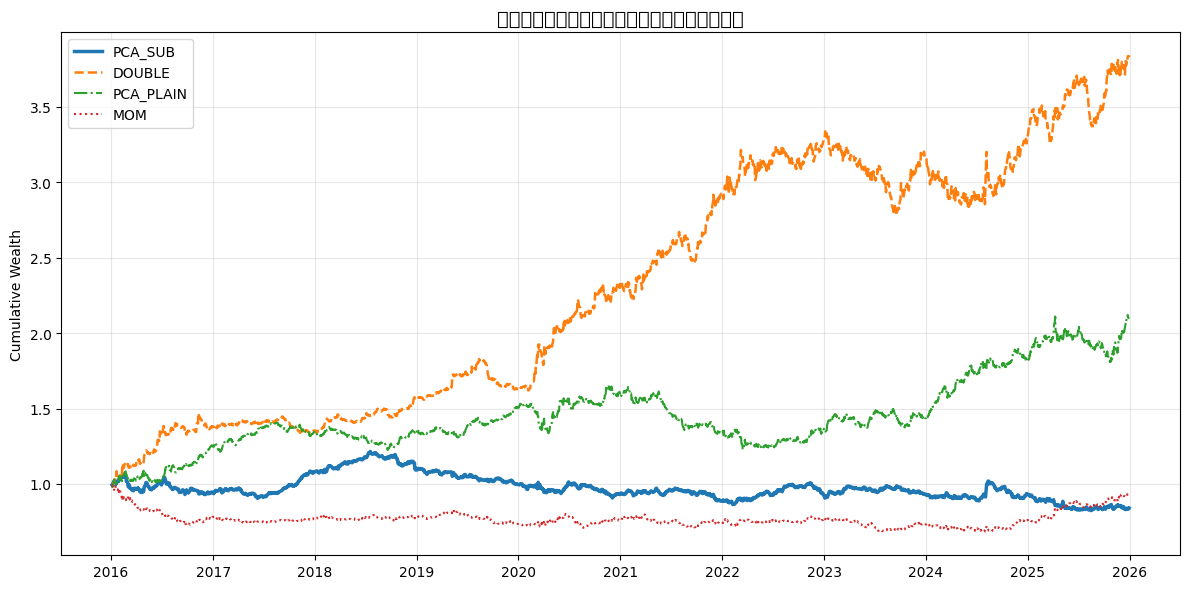

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))
styles = {"PCA_SUB":("tab:blue","-",2.5), "DOUBLE":("tab:orange","--",1.8),
          "PCA_PLAIN":("tab:green","-.",1.5), "MOM":("tab:red",":",1.5)}
for col,(color,ls,lw) in styles.items():
    cum = (1+ret_df[col].fillna(0)).cumprod()
    ax.plot(cum.index, cum.values, label=col, color=color, ls=ls, lw=lw)
ax.set_title("各戦略の累積リターン（日米業種リードラグ）", fontsize=14)
ax.set_ylabel("Cumulative Wealth"); ax.legend(); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

## 8. Fama-French / Carhart4 ファクター回帰 (任意)
が必要です。

In [ ]:
try:
    import pandas_datareader.data as web
    start_str = str(ret_df.index[0].date())
    end_str   = str(ret_df.index[-1].date())
    ff3 = web.DataReader("F-F_Research_Data_Factors_daily","famafrench",start=start_str,end=end_str)[0]/100
    mom = web.DataReader("F-F_Momentum_Factor_daily","famafrench",start=start_str,end=end_str)[0]/100
    mom.columns=["WML"]
    factors = ff3.join(mom,how="inner"); factors.index=pd.to_datetime(factors.index)

    def reg(s, xcols):
        df = pd.DataFrame({"R":s}).join(factors,how="inner").dropna()
        y  = df["R"].values
        X  = np.column_stack([np.ones(len(y)), df[xcols].values])
        b,_,_,_ = np.linalg.lstsq(X,y,rcond=None)
        resid = y - X@b
        lag=5; S=X.T@np.diag(resid**2)@X
        for l in range(1,lag+1):
            w=1-l/(lag+1); G=(X[l:]*resid[l:,None]).T@(X[:-l]*resid[:-l,None])
            S+=w*(G+G.T)
        V=len(y)*np.linalg.pinv(X.T@X)@S@np.linalg.pinv(X.T@X)
        se=np.sqrt(np.diag(V)/len(y)); t=b/(se+1e-12)
        row={"α(%/yr)":round(b[0]*252*100,2),"t(α)":round(t[0],2)}
        for i,fn in enumerate(xcols): row[fn]=round(b[i+1],3); row[f"t({fn})"]=round(t[i+1],2)
        return row

    print("--- FF3 ---")
    ff3_cols=["Mkt-RF","SMB","HML"]
    print(pd.DataFrame({c:reg(ret_df[c].dropna(),ff3_cols) for c in ret_df.columns}).T.to_string())
    print("--- Carhart4 ---")
    c4_cols=["Mkt-RF","SMB","HML","WML"]
    print(pd.DataFrame({c:reg(ret_df[c].dropna(),c4_cols) for c in ret_df.columns}).T.to_string())
except Exception as e:
    print(f"FF factors取得失敗: {e}")

--- FF3 ---
           α(%/yr)  t(α)  Mkt-RF  t(Mkt-RF)    SMB  t(SMB)    HML  t(HML)
PCA_SUB      -0.51 -0.19   0.001       0.05 -0.036   -2.11 -0.014   -1.10
PCA_PLAIN     6.78  2.07  -0.005      -0.34  0.046    1.99 -0.020   -1.18
MOM           0.29  0.11  -0.006      -0.48  0.007    0.36  0.010    0.78
DOUBLE       15.88  4.49  -0.124      -5.61  0.013    0.51 -0.063   -3.44
--- Carhart4 ---
           α(%/yr)  t(α)  Mkt-RF  t(Mkt-RF)    SMB  t(SMB)    HML  t(HML)    WML  t(WML)
PCA_SUB      -0.49 -0.18  -0.000      -0.02 -0.039   -2.26 -0.017   -1.32 -0.009   -0.81
PCA_PLAIN     6.79  2.07  -0.006      -0.41  0.043    1.80 -0.023   -1.39 -0.009   -0.68
MOM           0.29  0.11  -0.006      -0.48  0.007    0.33  0.010    0.72 -0.001   -0.06
DOUBLE       15.92  4.49  -0.126      -5.70  0.006    0.22 -0.071   -3.63 -0.020   -1.49
